In [ ]:
import sys
sys.path.append('..')  # go up one level to project/ to get the helper functions
import matplotlib.pyplot as plt
from eyetracking_helper import *

In [2]:
# load in eyetracking data for subject
subject = "KLR"
condition = "match" # let's work with match for this project
runtype = None # if you want to get ALL data, which we do. we want to make ALL the features

eyetracking_data = load_reportattn_eyetracking(subject, condition, runtype=runtype)

In [3]:
# let's print out the keys of the eyetracking data to see what movies we have
print(f"Keys of eyetracking data for {subject} in report-{condition}:")
for key in sorted(eyetracking_data.keys()):
    print(f"    {key}")

Keys of eyetracking data for KLR in report-match:
    test2match_run-03
    test2match_run-04
    test2match_run-05
    test2match_run-06
    train01match
    train02match
    train03match
    train04match
    train05match
    train06match
    train07match
    train08match
    train09match
    train10match


In [4]:
# this gives us a dictinoary of dataframes, one for each movie, with X,Y coordinates across the entire movie
print(f"Shape of eyetracking data for {subject} in report-{condition}, (samples,XY):", eyetracking_data['train01match'].shape)


Shape of eyetracking data for KLR in report-match, (samples,XY): (73852, 2)


In [5]:
# let's look at the length of the test movies, which are the ones that are the same length but may have different samplings due to error
for key in sorted(eyetracking_data.keys()):
    if 'test' in key:
        print(f"Shape of eyetracking data for {key}: {eyetracking_data[key].shape}")

Shape of eyetracking data for test2match_run-03: (45324, 2)
Shape of eyetracking data for test2match_run-04: (45328, 2)
Shape of eyetracking data for test2match_run-05: (45326, 2)
Shape of eyetracking data for test2match_run-06: (45329, 2)


they're all pretty close!

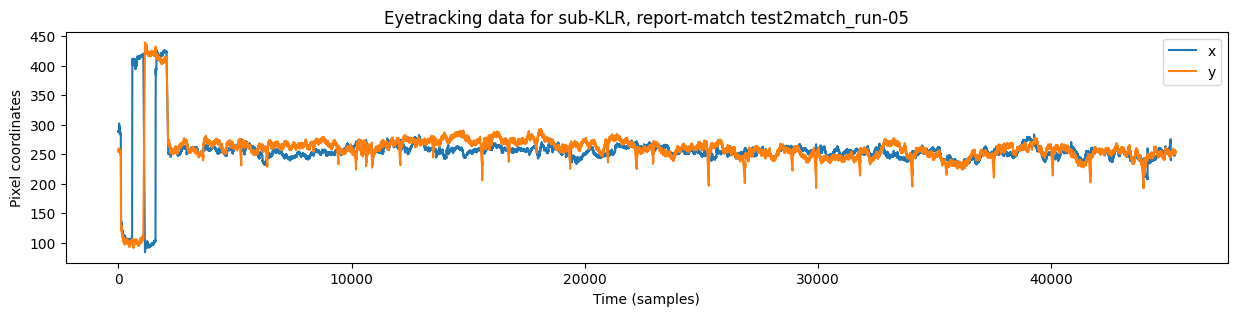

In [6]:
# let's plot the eyetracking across time for one of the test movies to see if it looks reasonable
plot_xy_timeseries(eyetracking_data, subject, condition)

# we can see the beginning of the movie, where the subject was tracking the fixation point! 
# and the fixation is pretty good for KLR!

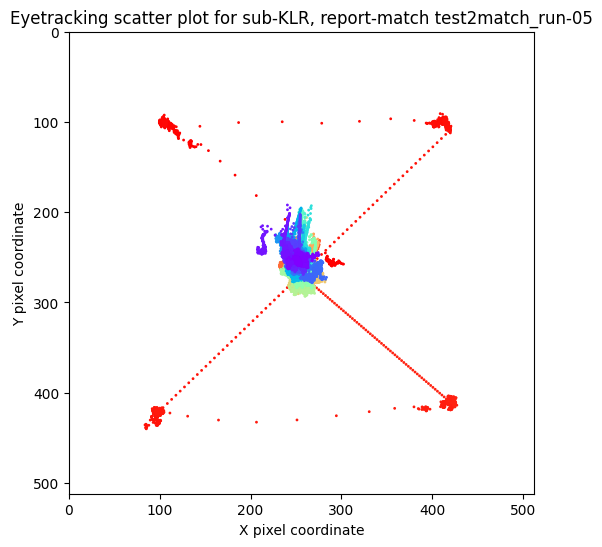

In [7]:
# let's visualize ON the visual stimulus
plot_scatter_xy(eyetracking_data, subject, condition)

In [8]:
# now let's look at divergence from fixation, which should be at 256,256 for the center of the movie
mean_divergence = {}
std_divergence = {}
verbose = False
for key in sorted(eyetracking_data.keys()):
    # divergence == euclidean distance from center of the screen at each point in time
    # we remove the first 2500 samples, which are the fixation point, to look at divergence during the movie
    divergence = np.sqrt((eyetracking_data[key]['x'][2500:] - 256) ** 2 + (eyetracking_data[key]['y'][2500:] - 256) ** 2)
    # print the mean divergence from center for this movie
    if verbose:
        print(f'For movie {key}:')
        print(f"    Mean divergence from center for {key}: {divergence.mean():.2f} pixels")
        # print the std of the divergence from center for this movie. 
        print(f"    Std of divergence from center for {key}: {divergence.std():.2f} pixels")
    mean_divergence[key] = divergence.mean()
    std_divergence[key] = divergence.std()

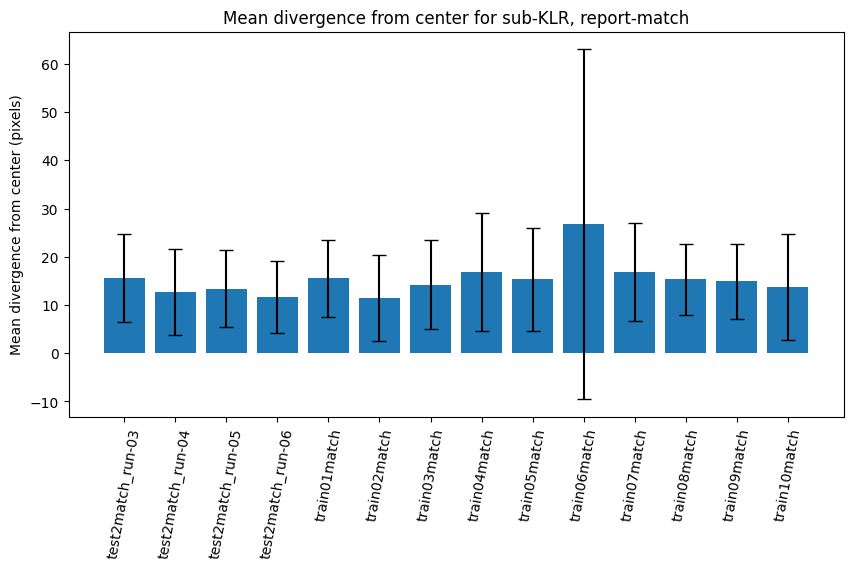

In [9]:
# shall we make a bar plot of the mean divergence from center for each movie? with std as error bars?
plt.figure(figsize=(10,5))
plt.bar(mean_divergence.keys(), mean_divergence.values(), yerr=std_divergence.values(), capsize=5)
plt.xticks(rotation=80)
plt.ylabel('Mean divergence from center (pixels)')
plt.title(f'Mean divergence from center for sub-{subject}, report-{condition}')
plt.show()


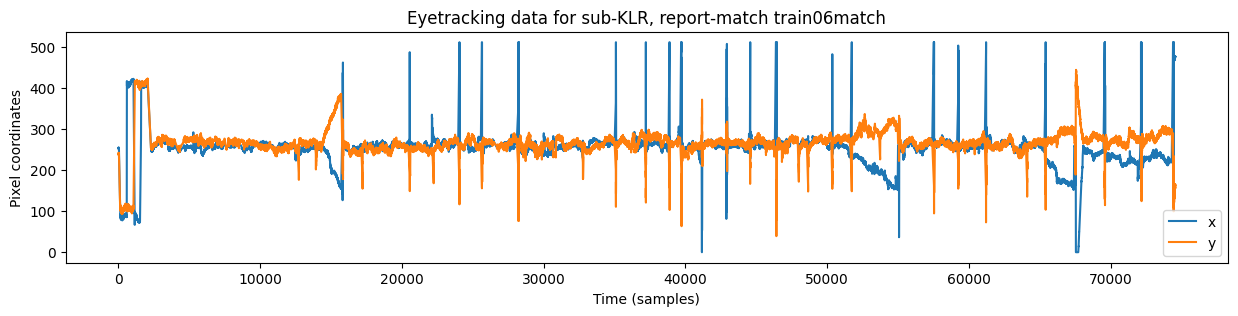

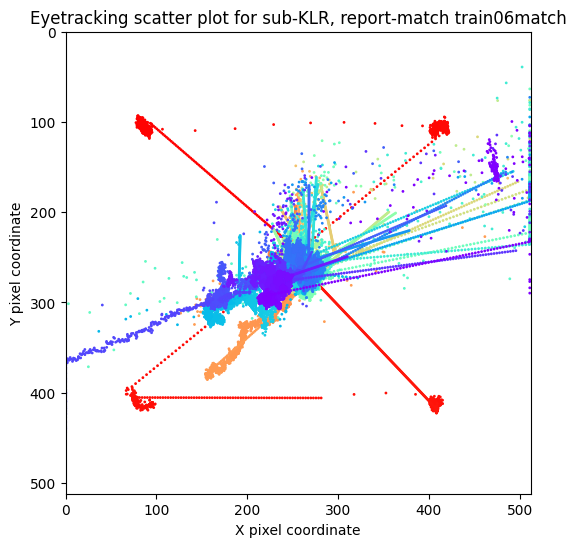

In [10]:

# we can see there was a LOT of divergence for train06match, so let's plot the time series for that one
plot_xy_timeseries(eyetracking_data, subject, condition, test_movie_key='train06match')
plot_scatter_xy(eyetracking_data, subject, condition, test_movie_key='train06match')


we can see that KLR train06 match has many spikes where X goes to the right side of the movie.  
this could be bad data, or blinks...

TODO: look into this

regardless, KLR is an awesome subject WRT fixation. let's look at other subjects

In [11]:
all_eyetracking = dict()
for subject in ['KLR', 'AOZ', 'AH', 'LSE', 'ZXI', 'UJQ']:
    runtype = None
    eyetracking_data = load_reportattn_eyetracking(subject, condition, runtype=runtype)
    all_eyetracking[subject] = eyetracking_data

Error loading /hehe/data/preproc/01_mri-bids/GOOD_DATA/report-attn-eyetracking/sub-AH/ses-report03/sub-AH_ses-report03_task-test2match03_run-01_corrected.npy: No data left in file


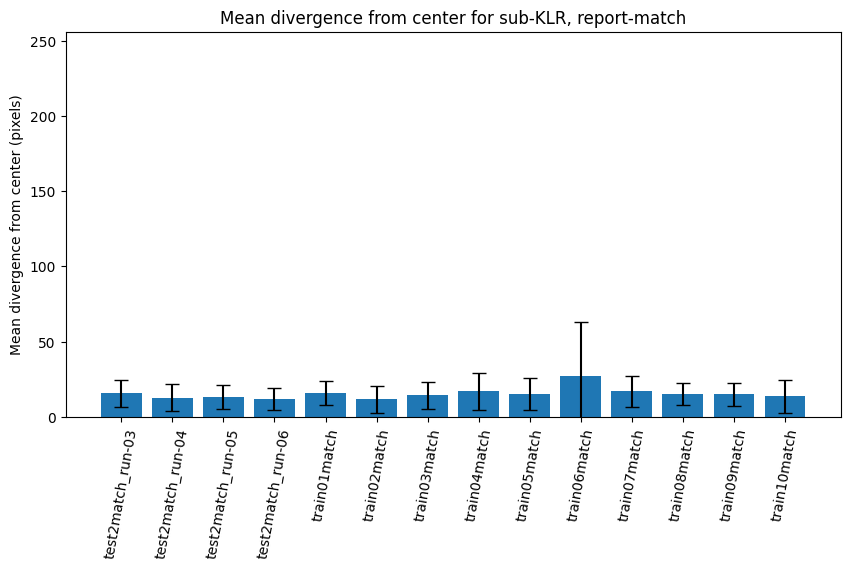

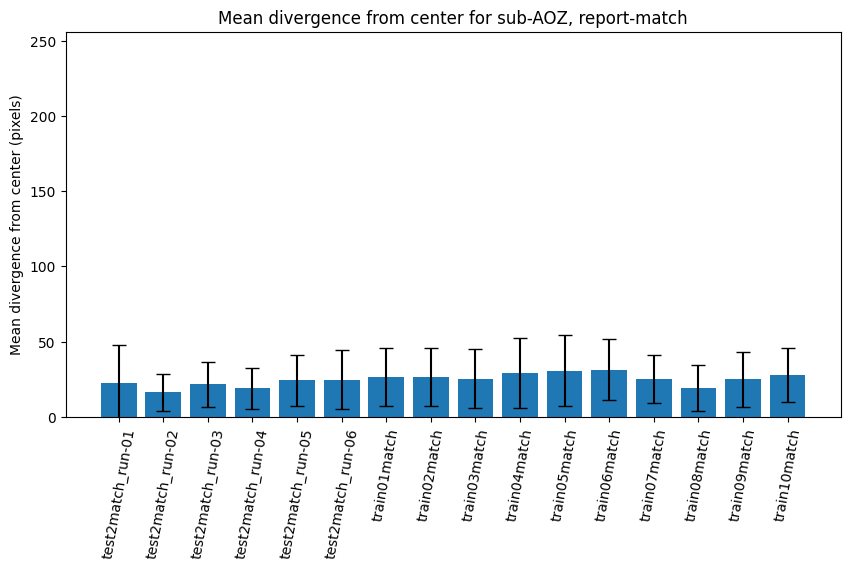

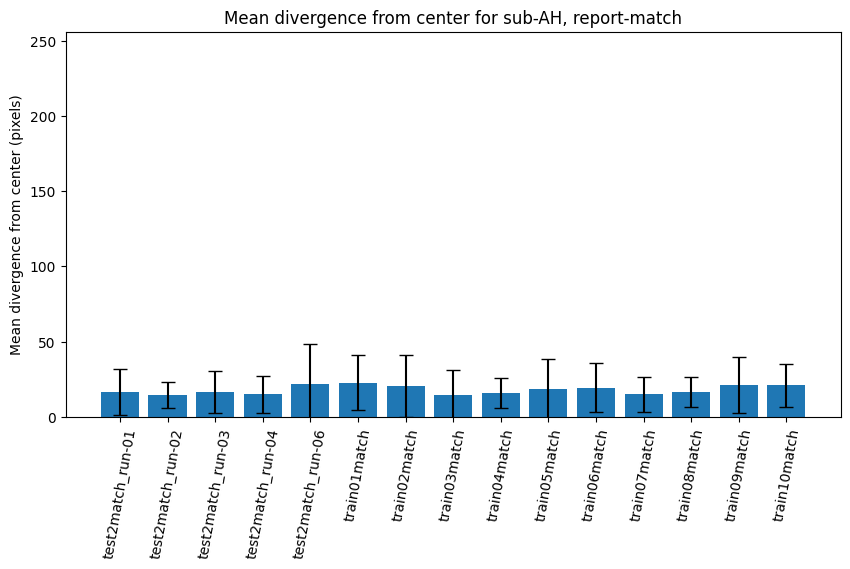

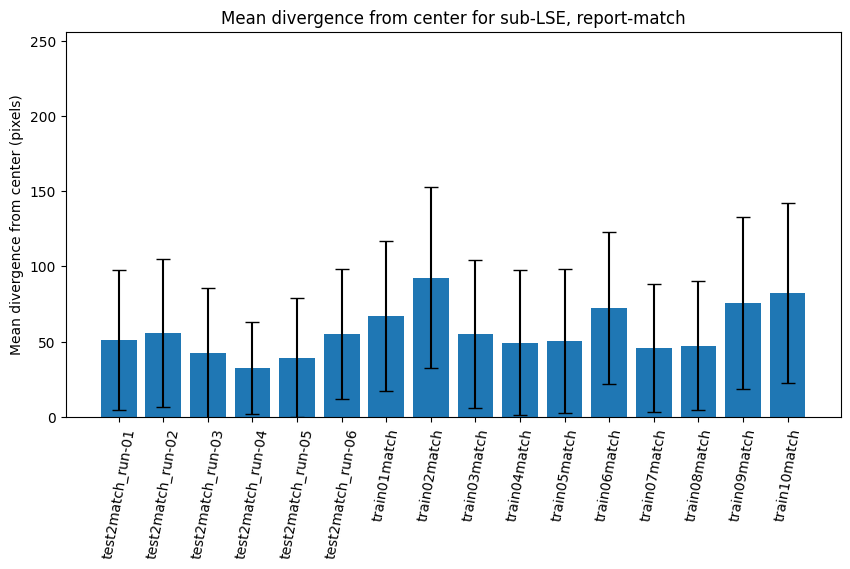

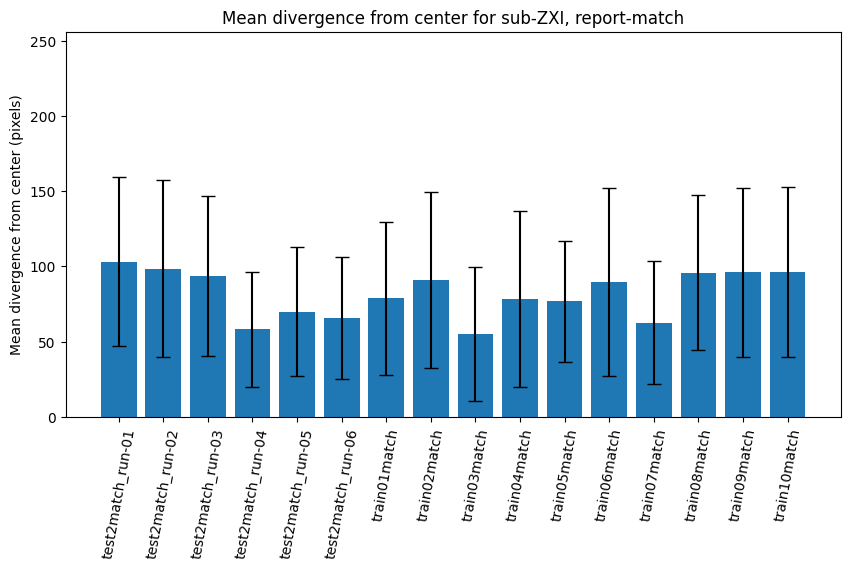

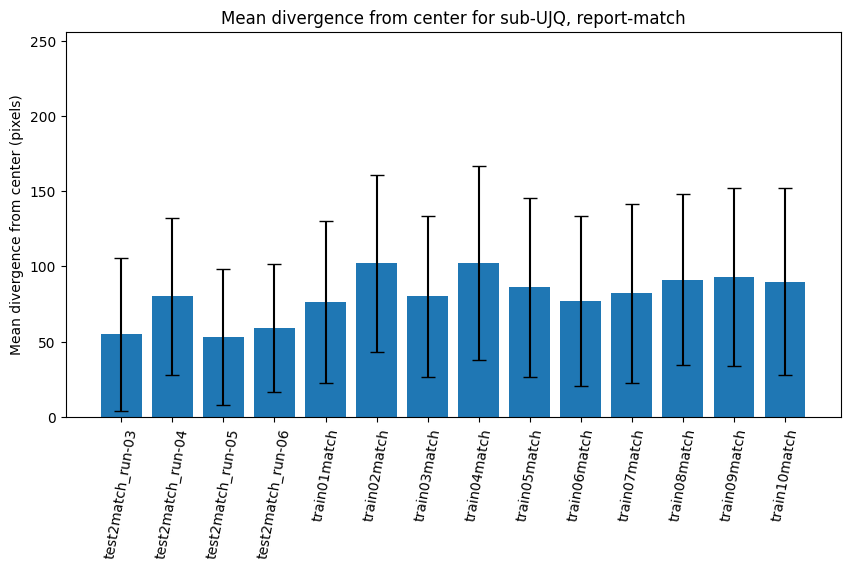

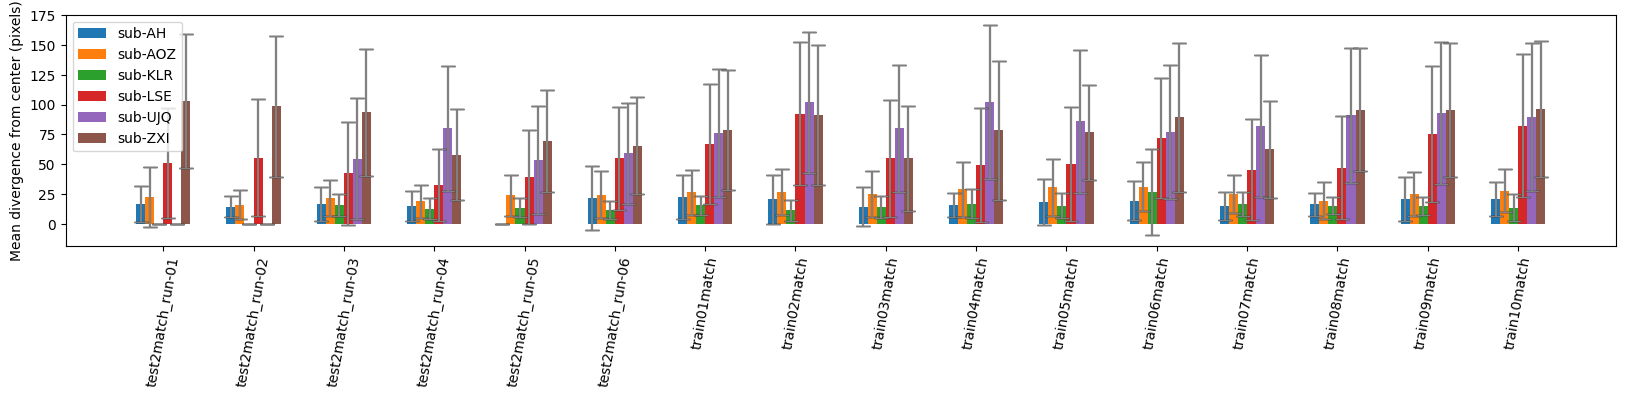

In [12]:
# let's get mean divergence from center for each subject and each movie, and make a bar plot for each subject
for subject in all_eyetracking.keys():
    mean_divergence = {}
    std_divergence = {}
    for key in sorted(all_eyetracking[subject].keys()):
        divergence = np.sqrt((all_eyetracking[subject][key]['x'][2500:] - 256) ** 2 + (all_eyetracking[subject][key]['y'][2500:] - 256) ** 2)
        mean_divergence[key] = divergence.mean()
        std_divergence[key] = divergence.std()
    
    plt.figure(figsize=(10,5))
    plt.bar(mean_divergence.keys(), mean_divergence.values(), yerr=std_divergence.values(), capsize=5)
    plt.xticks(rotation=80)
    plt.ylabel('Mean divergence from center (pixels)')
    plt.title(f'Mean divergence from center for sub-{subject}, report-{condition}')
    plt.ylim(0,256)
    plt.show()

# now let's make grouped bar plots to visualize all subjets at the same time.
# if a run is missing for a subject, skip it, but have it fo rother subjects
import numpy as np
import matplotlib.pyplot as plt
subjects = sorted(all_eyetracking.keys())
# get all possible movies that any subject may have watched
movies = set()
for subject in subjects:
    movies.update(all_eyetracking[subject].keys())
movies = sorted(movies)
x = np.arange(len(movies))  # the label locations
width = 0.1  # the width of the bars
plt.figure(figsize=(20,3))
for i, subject in enumerate(subjects):
    mean_divergence = []
    std_divergence = []
    for movie in movies:
        if movie in all_eyetracking[subject]:
            divergence = np.sqrt((all_eyetracking[subject][movie]['x'][2500:] - 256) ** 2 + (all_eyetracking[subject][movie]['y'][2500:] - 256) ** 2)
            mean_divergence.append(divergence.mean())
            std_divergence.append(divergence.std())
        else:
            mean_divergence.append(0)
            std_divergence.append(0)
    plt.bar(x + i*width, mean_divergence, width, yerr=std_divergence, capsize=5, label=f'sub-{subject}')
    # change color of yerr to grey
    plt.errorbar(x + i*width, mean_divergence, yerr=std_divergence, fmt='none', ecolor='grey', capsize=5)
plt.xticks(x + width*(len(subjects)-1)/2, movies, rotation=80)
plt.ylabel('Mean divergence from center (pixels)')
plt.legend()

In [14]:
# for subjects LSE, ZXI, UJQ, plot scatter for every movie to see if there are any patterns in the divergence.
# if you runt his, it will populate A LOT of figures below, so commented out for now
# for subject in ['LSE', 'ZXI', 'UJQ']:
#     for movie in sorted(all_eyetracking[subject].keys()):
#         plot_scatter_and_timeseries(all_eyetracking[subject], subject, condition, test_movie_key=movie)

In [ ]:
# shall we plot the eyetracking ON the movies for sanity check? yes
# run `python /hehe/projects/gaze-corrected-semantics/jen_reference/scripts/overlay-gaze-on-video.py EXPERIMENT SUBJECT CONDITION` to generate movies